# Simple signals and their power spectra

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram

In [7]:

dt = 0.001 # sec
fsignal = 10

n = int(fsignal*1e2)
tvec = np.arange(n)*dt


sine1 = np.sin(2*np.pi*fsignal*tvec)
sine2 = np.sin(2*np.pi*(5*fsignal)*tvec)

noise1 = np.random.randn(n)
noise2 = np.random.randn(n)*10



fs, pxx_noise1 = periodogram(noise1, fs=1/dt)
_, pxx_noise2 = periodogram(noise2, fs=1/dt)
_, pxx_sine1 = periodogram(sine1, fs=1/dt)
_, pxx_sine2 = periodogram(sine2, fs=1/dt)


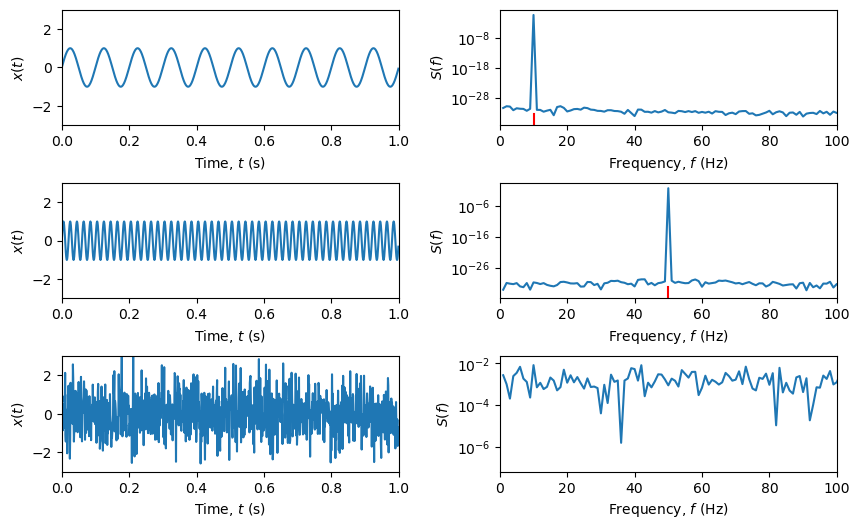

In [10]:
f, axs = plt.subplots(3,2, figsize=(10,6))

plt.subplots_adjust(hspace=0.5, wspace=0.3)

# axs[0, 0].plot(tvec, noise2)
# axs[0, 1].plot(fs, pxx_noise2)

axs[0, 0].plot(tvec, sine1)
axs[0, 1].semilogy(fs[1:-1], pxx_sine1[1:-1])
axs[0, 1].axvline(fsignal, color='r', ls='-', ymax=0.1)

axs[2, 0].plot(tvec, noise1)
axs[2, 1].semilogy(fs[1:-1], pxx_noise1[1:-1])

axs[1, 0].plot(tvec, sine2)
axs[1, 1].semilogy(fs[1:-1], pxx_sine2[1:-1])
axs[1,1].axvline(5*fsignal, color='r',  ls='-', ymax=0.1)

for ax in axs[:,0]:
    ax.set_xlim(0,1)
    ax.set_ylim(-3,3)
    ax.set_xlabel('Time, $t$ (s)')
    ax.set_ylabel('$x(t)$')
    
for ax in axs[:,1]:
    ax.set_xlabel('Frequency, $f$ (Hz)')
    ax.set_ylabel('$S(f)$')
    ax.set_xlim(0,100)
    
plt.savefig('Illustration_of_power_spectra.pdf', bbox_inches='tight')